# DDoS CV + SetD Normal Mix Comparison (ClassWeight, Baseline Features)

This notebook compares two training regimes using the baseline feature set and model-level class_weight.

Regime A:
- Train/validate on pooled SetA+SetB+SetC with 3-fold CV + Optuna HPO
- Final evaluation on SetD holdout

Regime B:
- Same as Regime A, but add 10% of SetD Normal traffic to the training pool
- Holdout uses the remaining SetD (excluding sampled normals)

Objective: mean DDoS attack F1 across folds
Models: random_forest, boosting, logistic_regression

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import optuna
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_recall_curve,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

print("Imports loaded.")

/home/aron/miniconda3/envs/tf/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports loaded.


In [2]:
# Experiment config
DATA_DIR = Path("ddos-data-2024")
OUT_DIR = Path("ddos-detection/model_comparison_optuna_kfold_setd_normal_mix")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_RECORDINGS = [
    "SCLDDoS2024_SetA",
    "SCLDDoS2024_SetB",
    "SCLDDoS2024_SetC",
]
HOLDOUT_RECORDING = "SCLDDoS2024_SetD"

TARGET_COL = "type"
NORMAL_CLASS = "Normal traffic"
NORMAL_SAMPLE_FRAC = 0.10

N_SPLITS = 3
N_OPTUNA_TRIALS = 6
OPTUNA_TARGET_CLASS = "DDoS attack"

MODEL_NAMES = ["random_forest", "boosting", "logistic_regression"]
REGIMES = ["abc_only", "abc_plus_setd_normal"]

EVENTS_COLS = [
    "Attack ID", "Card", "Victim IP", "Port number", "Attack code", "Detect count",
    "Packet speed", "Data speed", "Avg packet len", "Avg source IP count",
    "Start time", "End time", "Type",
]

COMP_COLS = [
    "Attack ID", "Detect count", "Card", "Victim IP", "Port number", "Attack code",
    "Packet speed", "Data speed", "Avg packet len", "Source IP count", "Time",
]

print("Data dir:", DATA_DIR.resolve())
print("Output dir:", OUT_DIR.resolve())
print("Train recordings:", TRAIN_RECORDINGS)
print("Holdout recording:", HOLDOUT_RECORDING)
print("CV folds:", N_SPLITS)
print("Optuna trials per HPO:", N_OPTUNA_TRIALS)
print("Normal sample fraction:", NORMAL_SAMPLE_FRAC)

Data dir: /home/aron/ml/halado_adatelemzesi_modszerek/ddos-data-2024
Output dir: /home/aron/ml/halado_adatelemzesi_modszerek/ddos-detection/model_comparison_optuna_kfold_setd_normal_mix
Train recordings: ['SCLDDoS2024_SetA', 'SCLDDoS2024_SetB', 'SCLDDoS2024_SetC']
Holdout recording: SCLDDoS2024_SetD
CV folds: 3
Optuna trials per HPO: 6
Normal sample fraction: 0.1


In [3]:
# Optional gradient boosting backend selection
BOOSTING_BACKEND = "histgb"

try:
    from xgboost import XGBClassifier
    BOOSTING_BACKEND = "xgboost"
except Exception:
    try:
        from lightgbm import LGBMClassifier
        BOOSTING_BACKEND = "lightgbm"
    except Exception:
        BOOSTING_BACKEND = "histgb"

print(f"Boosting backend selected: {BOOSTING_BACKEND}")

Boosting backend selected: lightgbm


In [4]:
def _to_snake_case(name: str) -> str:
    name = name.strip().lower()
    name = re.sub(r"[^a-z0-9]+", "_", name)
    return re.sub(r"_+", "_", name).strip("_")


def _safe_mode(series: pd.Series):
    vals = series.mode(dropna=True)
    return vals.iloc[0] if not vals.empty else np.nan


def preprocess_recordings(recordings, data_dir=DATA_DIR, verbose=True):
    events_frames = []
    comp_frames = []

    for recording in recordings:
        events_path = Path(data_dir) / f"{recording}_events.csv"
        comp_path = Path(data_dir) / f"{recording}_components.csv"

        if not events_path.exists() or not comp_path.exists():
            raise FileNotFoundError(f"Missing CSV for recording {recording} in {data_dir}")

        events = pd.read_csv(events_path, usecols=EVENTS_COLS)
        comps = pd.read_csv(comp_path, usecols=COMP_COLS)

        events["recording"] = recording
        comps["recording"] = recording

        events_frames.append(events)
        comp_frames.append(comps)

        if verbose:
            print(f"[load] {recording}: events={len(events)}, components={len(comps)}")

    events = pd.concat(events_frames, ignore_index=True)
    comps = pd.concat(comp_frames, ignore_index=True)

    if verbose:
        print(f"[combined] events={len(events)}, components={len(comps)}")

    events = events.drop_duplicates().copy()
    comps = comps.drop_duplicates().copy()

    events["Start time"] = pd.to_datetime(events["Start time"], errors="coerce")
    events["End time"] = pd.to_datetime(events["End time"], errors="coerce")
    comps["Time"] = pd.to_datetime(comps["Time"], errors="coerce")

    events = events.dropna(subset=["Attack ID", "Type", "Start time", "End time"]).copy()
    comps = comps.dropna(subset=["Attack ID", "Time"]).copy()

    events = events.loc[events["End time"] >= events["Start time"]].copy()

    valid_ids = set(events["Attack ID"].unique())
    comps = comps.loc[comps["Attack ID"].isin(valid_ids)].copy()

    events["event_duration_sec"] = (events["End time"] - events["Start time"]).dt.total_seconds()
    events["day_of_week"] = events["Start time"].dt.dayofweek
    events["hour_of_day"] = events["Start time"].dt.hour
    events["is_weekend"] = (events["day_of_week"] >= 5).astype(int)

    events["packet_data_ratio"] = events["Packet speed"] / (events["Data speed"].replace(0, np.nan))
    events["packet_data_ratio"] = events["packet_data_ratio"].replace([np.inf, -np.inf], np.nan)
    events["attack_intensity"] = events["Packet speed"] * events["Avg source IP count"]

    comp_agg = (
        comps.groupby("Attack ID", as_index=False)
        .agg(
            comp_row_count=("Detect count", "size"),
            comp_detect_count_max=("Detect count", "max"),
            comp_packet_speed_mean=("Packet speed", "mean"),
            comp_packet_speed_max=("Packet speed", "max"),
            comp_packet_speed_std=("Packet speed", "std"),
            comp_avg_packet_len_mean=("Avg packet len", "mean"),
            comp_source_ip_count_mean=("Source IP count", "mean"),
            comp_source_ip_count_max=("Source IP count", "max"),
            comp_attack_code_mode=("Attack code", _safe_mode),
            comp_card_mode=("Card", _safe_mode),
            comp_first_time=("Time", "min"),
            comp_last_time=("Time", "max"),
        )
        .copy()
    )

    comp_agg["comp_packet_speed_std"] = comp_agg["comp_packet_speed_std"].fillna(0)
    comp_agg["comp_duration_sec"] = (comp_agg["comp_last_time"] - comp_agg["comp_first_time"]).dt.total_seconds()
    comp_agg["source_ip_growth_rate"] = np.where(
        comp_agg["comp_duration_sec"] > 0,
        comp_agg["comp_source_ip_count_max"] / comp_agg["comp_duration_sec"],
        0.0,
    )

    events = events.sort_values("Start time").drop_duplicates(subset=["Attack ID"], keep="last").copy()
    merged = events.merge(comp_agg, on="Attack ID", how="left")

    merged = merged.drop(columns=["Victim IP", "Data speed"], errors="ignore")
    merged.columns = [_to_snake_case(c) for c in merged.columns]

    num_cols = merged.select_dtypes(include=["number"]).columns
    obj_cols = merged.select_dtypes(exclude=["number"]).columns
    merged[num_cols] = merged[num_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
    merged[obj_cols] = merged[obj_cols].fillna("missing")

    if verbose:
        print(f"[preprocess] rows={len(merged)}, cols={merged.shape[1]}")

    return merged

In [5]:
recordings_all = TRAIN_RECORDINGS + [HOLDOUT_RECORDING]
recording_frames = {}
for rec in recordings_all:
    recording_frames[rec] = preprocess_recordings([rec], data_dir=DATA_DIR, verbose=True)

abc_all = pd.concat([recording_frames[rec] for rec in TRAIN_RECORDINGS], ignore_index=True)
setd_all = recording_frames[HOLDOUT_RECORDING].copy()

setd_normals = setd_all[setd_all[TARGET_COL] == NORMAL_CLASS].copy()
setd_normals_sample = setd_normals.sample(frac=NORMAL_SAMPLE_FRAC, random_state=RANDOM_STATE)
setd_holdout = setd_all.drop(index=setd_normals_sample.index).copy()

regime_pools = {
    "abc_only": abc_all,
    "abc_plus_setd_normal": pd.concat([abc_all, setd_normals_sample], ignore_index=True),
}

print("ABC pool shape:", abc_all.shape)
print("SetD total shape:", setd_all.shape)
print("SetD normals total:", len(setd_normals))
print("SetD normals sampled (10%):", len(setd_normals_sample))
print("SetD holdout (remaining) shape:", setd_holdout.shape)

print("\nABC class distribution:")
display(abc_all[TARGET_COL].value_counts())
print("SetD holdout class distribution:")
display(setd_holdout[TARGET_COL].value_counts())

[load] SCLDDoS2024_SetA: events=134770, components=586642
[combined] events=134770, components=586642
[preprocess] rows=134766, cols=32
[load] SCLDDoS2024_SetB: events=130000, components=1233449
[combined] events=130000, components=1233449
[preprocess] rows=130000, cols=32
[load] SCLDDoS2024_SetC: events=130000, components=1247266
[combined] events=130000, components=1247266
[preprocess] rows=129999, cols=32
[load] SCLDDoS2024_SetD: events=437657, components=2452610
[combined] events=437657, components=2452610
[preprocess] rows=437639, cols=32
ABC pool shape: (394765, 32)
SetD total shape: (437639, 32)
SetD normals total: 394482
SetD normals sampled (10%): 39448
SetD holdout (remaining) shape: (398191, 32)

ABC class distribution:


type
Normal traffic        374905
Suspicious traffic     16432
DDoS attack             3428
Name: count, dtype: int64

SetD holdout class distribution:


type
Normal traffic        355034
Suspicious traffic     28424
DDoS attack            14733
Name: count, dtype: int64

In [6]:
LEAKAGE_DROP_COLS = [
    TARGET_COL,
    "attack_id",
    "recording",
    "start_time",
    "end_time",
    "comp_first_time",
    "comp_last_time",
    "attack_code",
    "comp_attack_code_mode",
    "card",
    "comp_card_mode"
]

def split_xy(df: pd.DataFrame, target_col: str = TARGET_COL):
    usable_drop = [c for c in LEAKAGE_DROP_COLS if c in df.columns]
    X = df.drop(columns=usable_drop).copy()
    y = df[target_col].copy()
    return X, y

def build_preprocessor(X_fit: pd.DataFrame):
    cat_cols = X_fit.select_dtypes(include=["object", "string", "category", "bool"]).columns.tolist()
    num_cols = X_fit.select_dtypes(include=["number"]).columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]),
                num_cols,
            ),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]),
                cat_cols,
            ),
        ],
        remainder="drop",
    )
    return preprocessor

def to_dense(X):
    return X.toarray() if hasattr(X, "toarray") else np.asarray(X)

def build_baseline_features(X_fit_raw: pd.DataFrame, X_eval_raw: pd.DataFrame):
    preprocessor = build_preprocessor(X_fit_raw)
    X_fit = to_dense(preprocessor.fit_transform(X_fit_raw)).astype(np.float32)
    X_eval = to_dense(preprocessor.transform(X_eval_raw)).astype(np.float32)
    return X_fit, X_eval

pool_data = {}
for regime, df in regime_pools.items():
    X_raw, y = split_xy(df)
    pool_data[regime] = {"X_raw": X_raw, "y": y}

X_holdout_raw, y_holdout = split_xy(setd_holdout)
print("Holdout rows:", len(X_holdout_raw))

Holdout rows: 398191


In [7]:
def compute_multiclass_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
    }

def compute_f1_target_class(y_true, y_pred, target_class: str) -> float:
    labels_present = sorted(pd.Series(y_true).unique())
    scores = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=labels_present,
        zero_division=0,
    )[2]
    score_map = dict(zip(labels_present, scores))
    return float(score_map.get(target_class, 0.0))

def compute_prob_metrics(y_true, y_proba, class_labels):
    metrics = {}
    try:
        metrics["roc_auc_ovr_macro"] = roc_auc_score(
            y_true,
            y_proba,
            labels=class_labels,
            multi_class="ovr",
            average="macro",
        )
    except Exception:
        metrics["roc_auc_ovr_macro"] = np.nan

    y_bin = label_binarize(y_true, classes=class_labels)
    if y_bin.shape[1] == 1:
        metrics["pr_auc_macro"] = np.nan
    else:
        per_class_ap = []
        for i in range(y_bin.shape[1]):
            if y_bin[:, i].sum() == 0:
                continue
            per_class_ap.append(average_precision_score(y_bin[:, i], y_proba[:, i]))
        metrics["pr_auc_macro"] = float(np.mean(per_class_ap)) if per_class_ap else np.nan

    return metrics

def balanced_sample_weights(y: pd.Series) -> np.ndarray:
    classes = np.unique(y)
    class_w = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    class_map = dict(zip(classes, class_w))
    return y.map(class_map).values.astype(np.float32)

def align_proba_columns(model, y_proba, class_labels):
    aligned = pd.DataFrame(y_proba, columns=model.classes_)
    aligned = aligned.reindex(columns=class_labels, fill_value=0.0)
    return aligned.values

def build_ovr_curve_rows(y_true, y_proba, class_labels, model_name: str, regime: str):
    rows = []
    y_bin = label_binarize(y_true, classes=class_labels)
    if y_bin.ndim == 1:
        y_bin = y_bin.reshape(-1, 1)

    for idx, class_name in enumerate(class_labels):
        if idx >= y_bin.shape[1]:
            continue
        y_class = y_bin[:, idx]
        if y_class.sum() == 0 or y_class.sum() == len(y_class):
            continue

        fpr, tpr, _ = roc_curve(y_class, y_proba[:, idx])
        precision, recall, _ = precision_recall_curve(y_class, y_proba[:, idx])
        rows.append({
            "model": model_name,
            "regime": regime,
            "class_name": class_name,
            "roc_auc": float(auc(fpr, tpr)),
            "pr_auc": float(auc(recall, precision)),
            "avg_precision": float(average_precision_score(y_class, y_proba[:, idx])),
        })

    return rows

In [8]:
def suggest_params(trial: optuna.trial.Trial, model_name: str, backend: str):
    if model_name == "logistic_regression":
        return {
            "C": trial.suggest_float("C", 0.05, 20.0, log=True),
            "max_iter": trial.suggest_int("max_iter", 1000, 4000, step=500),
        }

    if model_name == "random_forest":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 100, 400, step=50),
            "max_depth": trial.suggest_int("max_depth", 8, 30, step=2),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        }

    if model_name == "boosting":
        if backend == "xgboost":
            return {
                "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=50),
                "max_depth": trial.suggest_int("max_depth", 3, 12),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            }

        if backend == "lightgbm":
            return {
                "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=50),
                "num_leaves": trial.suggest_int("num_leaves", 20, 100, step=5),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                "min_child_samples": trial.suggest_int("min_child_samples", 5, 30),
            }

        return {
            "max_iter": trial.suggest_int("max_iter", 100, 500, step=50),
            "max_depth": trial.suggest_int("max_depth", 4, 15),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        }

    raise ValueError(f"Unknown model_name: {model_name}")

def make_model(model_name: str, params: dict, use_class_weight: bool = True):
    if model_name == "logistic_regression":
        return LogisticRegression(
            solver="lbfgs",
            class_weight=("balanced" if use_class_weight else None),
            random_state=RANDOM_STATE,
            **params,
        )

    if model_name == "random_forest":
        return RandomForestClassifier(
            class_weight=("balanced_subsample" if use_class_weight else None),
            random_state=RANDOM_STATE,
            n_jobs=-1,
            **params,
        )

    if model_name == "boosting":
        if BOOSTING_BACKEND == "xgboost":
            return XGBClassifier(
                objective="multi:softprob",
                eval_metric="mlogloss",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                **params,
            )

        if BOOSTING_BACKEND == "lightgbm":
            return LGBMClassifier(
                objective="multiclass",
                class_weight=("balanced" if use_class_weight else None),
                random_state=RANDOM_STATE,
                **params,
            )

        return HistGradientBoostingClassifier(
            random_state=RANDOM_STATE,
            **params,
        )

    raise ValueError(f"Unknown model_name: {model_name}")

In [9]:
def tune_model_with_optuna_cv(regime_name: str, model_name: str):
    X_raw = pool_data[regime_name]["X_raw"]
    y = pool_data[regime_name]["y"]

    cv_splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    fold_indices = list(cv_splitter.split(X_raw, y))

    trial_rows = []
    fold_rows = []

    def objective(trial: optuna.trial.Trial) -> float:
        params = suggest_params(trial, model_name, BOOSTING_BACKEND)

        fold_f1_ddos = []
        fold_f1_macro = []
        fold_bal_acc = []
        fold_acc = []
        fold_fit_time = []

        for fold_idx, (train_idx, val_idx) in enumerate(fold_indices, start=1):
            X_train_raw = X_raw.iloc[train_idx].reset_index(drop=True)
            y_train = y.iloc[train_idx].reset_index(drop=True)
            X_val_raw = X_raw.iloc[val_idx].reset_index(drop=True)
            y_val = y.iloc[val_idx].reset_index(drop=True)

            X_train, X_val = build_baseline_features(X_train_raw, X_val_raw)

            model = make_model(model_name, params=params, use_class_weight=True)
            fit_kwargs = {}
            if model_name == "boosting" and BOOSTING_BACKEND in {"xgboost", "histgb"}:
                fit_kwargs["sample_weight"] = balanced_sample_weights(y_train)

            t0 = time.perf_counter()
            model.fit(X_train, y_train, **fit_kwargs)
            fit_time = time.perf_counter() - t0

            pred_val = model.predict(X_val)
            val_metrics = compute_multiclass_metrics(y_val, pred_val)
            f1_ddos_val = compute_f1_target_class(y_val, pred_val, OPTUNA_TARGET_CLASS)

            fold_f1_ddos.append(float(f1_ddos_val))
            fold_f1_macro.append(float(val_metrics["f1_macro"]))
            fold_bal_acc.append(float(val_metrics["balanced_accuracy"]))
            fold_acc.append(float(val_metrics["accuracy"]))
            fold_fit_time.append(float(fit_time))

            fold_rows.append({
                "regime": regime_name,
                "model": model_name,
                "trial_number": int(trial.number),
                "fold": int(fold_idx),
                "f1_ddos": float(f1_ddos_val),
                "f1_macro": float(val_metrics["f1_macro"]),
                "balanced_accuracy": float(val_metrics["balanced_accuracy"]),
                "accuracy": float(val_metrics["accuracy"]),
                "fit_time_sec": float(fit_time),
            })

        trial_rows.append({
            "regime": regime_name,
            "model": model_name,
            "trial_number": int(trial.number),
            "params": json.dumps(params, sort_keys=True),
            "mean_f1_ddos": float(np.mean(fold_f1_ddos)),
            "std_f1_ddos": float(np.std(fold_f1_ddos)),
            "mean_f1_macro": float(np.mean(fold_f1_macro)),
            "mean_balanced_accuracy": float(np.mean(fold_bal_acc)),
            "mean_accuracy": float(np.mean(fold_acc)),
            "mean_fit_time_sec": float(np.mean(fold_fit_time)),
            "cv_score_consistency": float(np.std(fold_f1_ddos) / max(np.mean(fold_f1_ddos), 1e-8)),
        })

        return float(np.mean(fold_f1_ddos))

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    )
    study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=False)

    trials_df_local = pd.DataFrame(trial_rows).sort_values(
        ["mean_f1_ddos", "mean_f1_macro", "mean_balanced_accuracy", "mean_accuracy"],
        ascending=[False, False, False, False],
    ).reset_index(drop=True)
    fold_df_local = pd.DataFrame(fold_rows)

    best_row = trials_df_local.iloc[0].copy()
    best_params = json.loads(best_row["params"])
    best_trial_number = int(best_row["trial_number"])
    best_fold_df = fold_df_local[fold_df_local["trial_number"] == best_trial_number].copy()

    return best_params, best_row, trials_df_local, fold_df_local, best_fold_df

all_tuning_rows = []
all_fold_rows = []
all_best_fold_rows = []
best_params_map = {}
best_trial_meta_rows = []

for regime in REGIMES:
    for model_name in MODEL_NAMES:
        print(f"Optuna CV HPO: {regime} / {model_name}")
        (
            best_params,
            best_row,
            trials_df_local,
            fold_df_local,
            best_fold_df,
        ) = tune_model_with_optuna_cv(regime, model_name)

        best_params_map[(regime, model_name)] = best_params
        all_tuning_rows.append(trials_df_local)
        all_fold_rows.append(fold_df_local)
        all_best_fold_rows.append(best_fold_df)
        best_trial_meta_rows.append(best_row.to_dict())

tuning_results_df = pd.concat(all_tuning_rows, ignore_index=True)
fold_metrics_df = pd.concat(all_fold_rows, ignore_index=True)
best_fold_metrics_df = pd.concat(all_best_fold_rows, ignore_index=True)
best_trials_df = pd.DataFrame(best_trial_meta_rows)

print("Best trials per regime/model:")
display(best_trials_df[["regime", "model", "trial_number", "mean_f1_ddos", "mean_f1_macro", "mean_balanced_accuracy", "mean_accuracy", "params"]])

Optuna CV HPO: abc_only / random_forest
Optuna CV HPO: abc_only / boosting
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001549 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4616
[LightGBM] [Info] Number of data points in the train set: 263176, number of used features: 21
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001658 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4617
[LightGBM] [Info] Number of data points in the train set: 263177, number of used features: 21
[LightGBM] [Info] Start training from score -1.098612
[

,regime,model,trial_number,mean_f1_ddos,mean_f1_macro,mean_balanced_accuracy,mean_accuracy,params
0,abc_only,random_forest,0,0.763018,0.852328,0.873277,0.978169,"{""max_depth"": 30, ""min_samples_leaf"": 4, ""n_es..."
1,abc_only,boosting,0,0.786256,0.864486,0.891495,0.979747,"{""learning_rate"": 0.1205712628744377, ""min_chi..."
2,abc_only,logistic_regression,1,0.091038,0.415039,0.735581,0.738057,"{""C"": 4.014783718209775, ""max_iter"": 3000}"
3,abc_plus_setd_normal,random_forest,0,0.765514,0.849220,0.872915,0.978893,"{""max_depth"": 30, ""min_samples_leaf"": 4, ""n_es..."
4,abc_plus_setd_normal,boosting,0,0.764064,0.852141,0.890510,0.979604,"{""learning_rate"": 0.1205712628744377, ""min_chi..."
5,abc_plus_setd_normal,logistic_regression,5,0.080247,0.428114,0.737045,0.770408,"{""C"": 0.05656295542959041, ""max_iter"": 4000}"


Cross-validation summary (best trial per regime/model):


mean_accuracy  mean_balanced_accuracy  mean_f1_ddos  mean_f1_macro  std_f1_ddos
regime               model                                                                                               
abc_only             boosting                  0.979747                0.891495      0.786256       0.864486     0.008286
                     logistic_regression       0.738057                0.735581      0.091038       0.415039     0.004404
                     random_forest             0.978169                0.873277      0.763018       0.852328     0.006004
abc_plus_setd_normal boosting                  0.979604                0.890510      0.764064       0.852141     0.007588
                     logistic_regression       0.770408                0.737045      0.080247       0.428114     0.000850
                     random_forest             0.978893                0.872915      0.765514       0.849220     0.008861

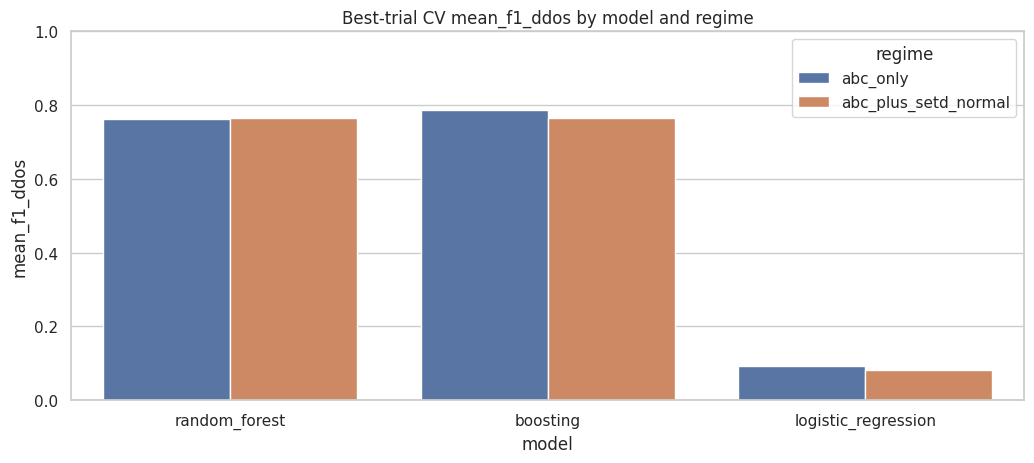

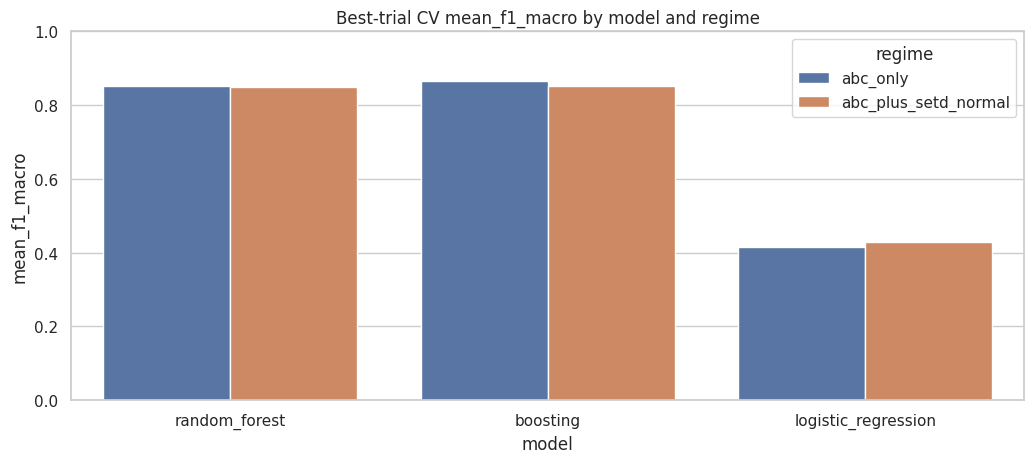

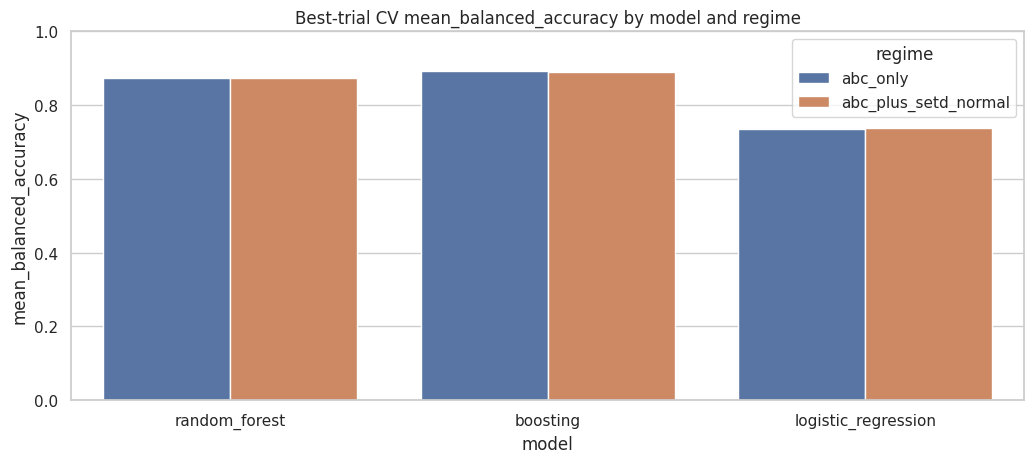

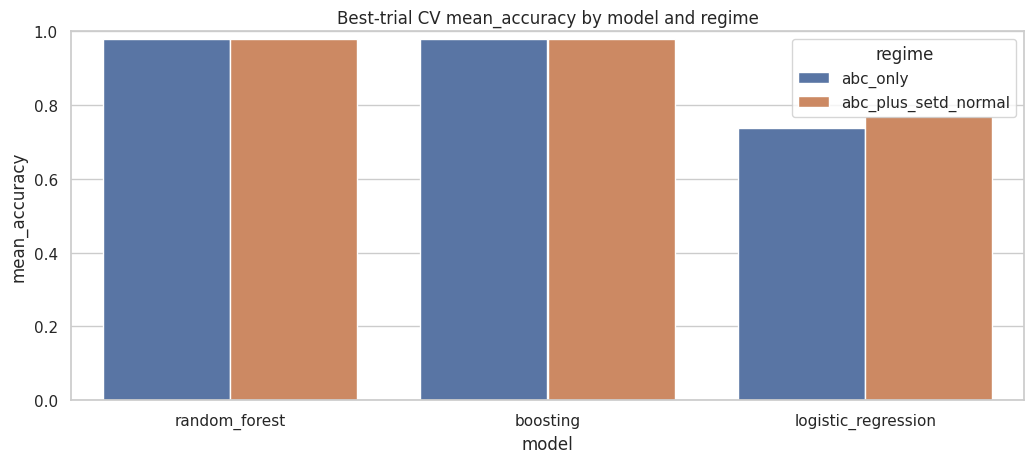

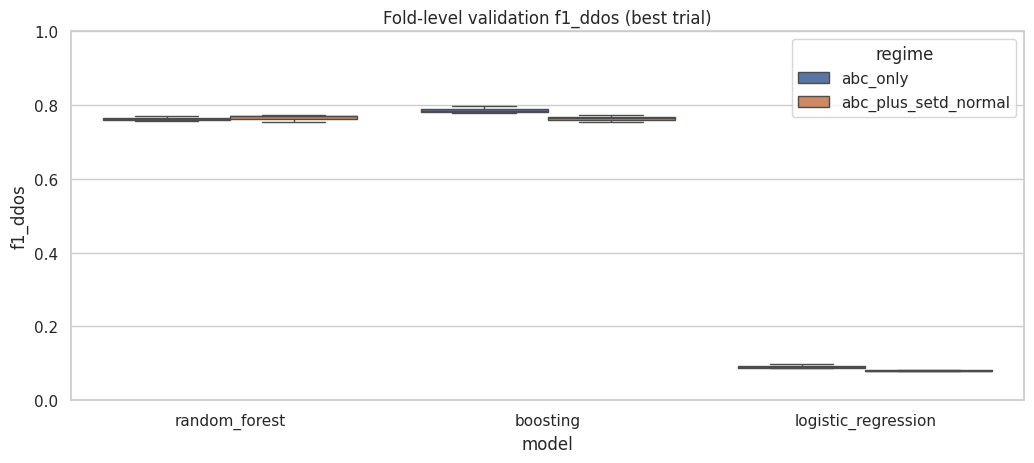

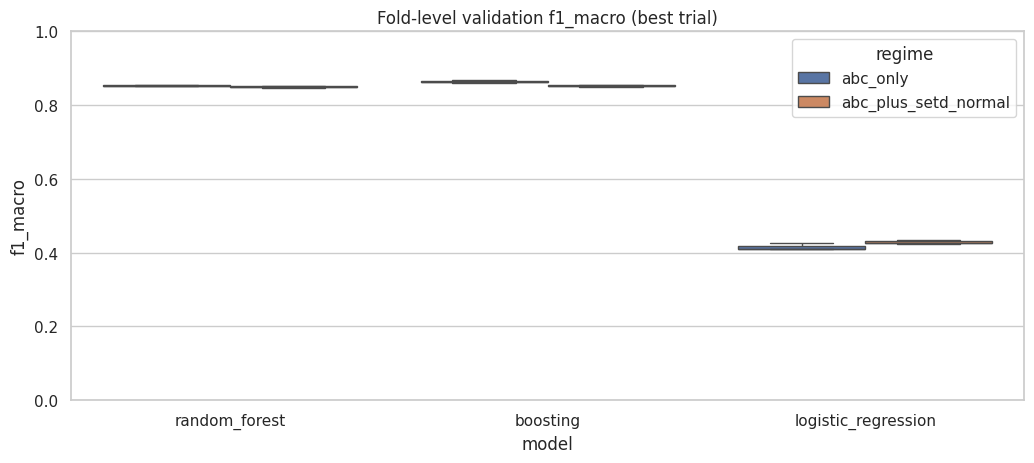

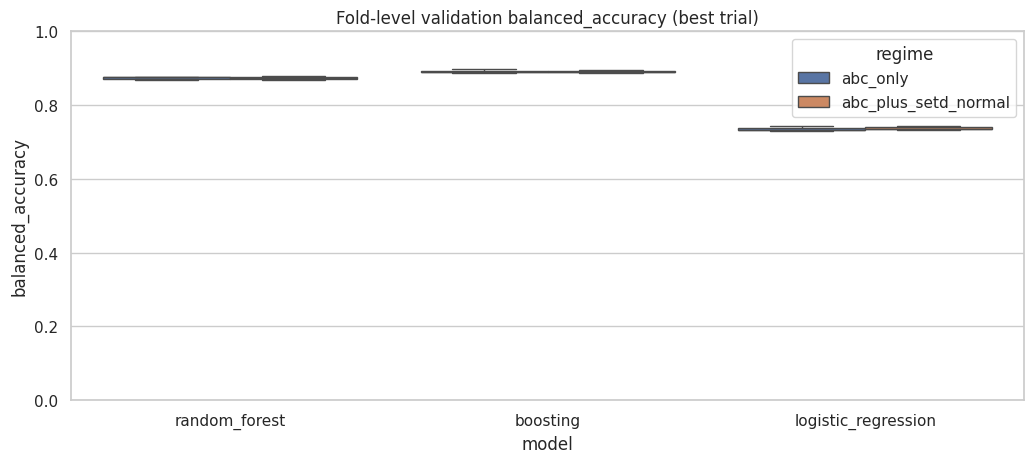

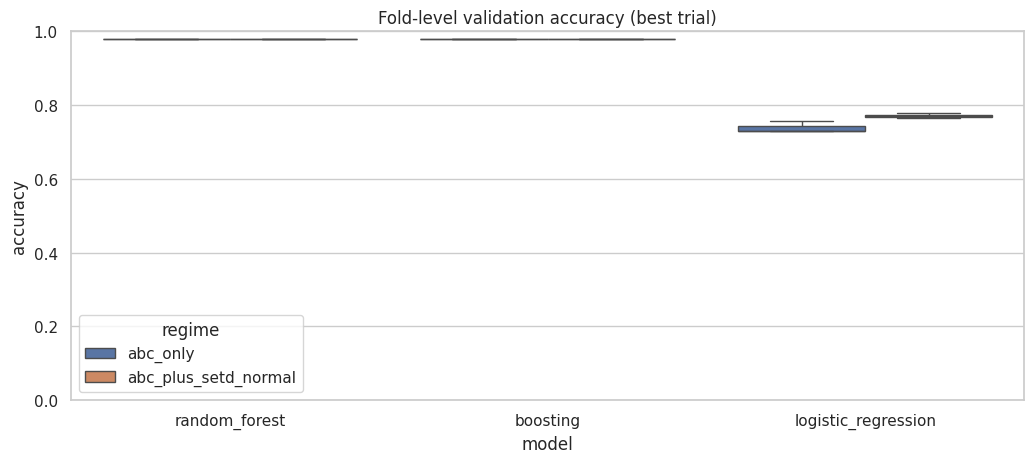

In [10]:
cv_summary_pivot = best_trials_df.pivot_table(
    index=["regime", "model"],
    values=["mean_f1_ddos", "mean_f1_macro", "mean_balanced_accuracy", "mean_accuracy", "std_f1_ddos"],
    aggfunc="mean",
)
print("Cross-validation summary (best trial per regime/model):")
display(cv_summary_pivot)

for metric in ["mean_f1_ddos", "mean_f1_macro", "mean_balanced_accuracy", "mean_accuracy"]:
    plt.figure(figsize=(10.5, 4.8))
    ax = sns.barplot(
        data=best_trials_df,
        x="model",
        y=metric,
        hue="regime",
        errorbar=None,
    )
    ax.set_ylim(0, 1)
    ax.set_title(f"Best-trial CV {metric} by model and regime")
    plt.tight_layout()
    plt.show()

for metric in ["f1_ddos", "f1_macro", "balanced_accuracy", "accuracy"]:
    plt.figure(figsize=(10.5, 4.8))
    ax = sns.boxplot(
        data=best_fold_metrics_df,
        x="model",
        y=metric,
        hue="regime",
    )
    ax.set_ylim(0, 1)
    ax.set_title(f"Fold-level validation {metric} (best trial)")
    plt.tight_layout()
    plt.show()

In [11]:
# Final holdout evaluation on remaining SetD
final_rows = []
per_class_rows = []
roc_pr_rows = []
final_predictions = {}
final_models = {}

for regime in REGIMES:
    X_pool_raw = pool_data[regime]["X_raw"].reset_index(drop=True)
    y_pool = pool_data[regime]["y"].reset_index(drop=True)
    class_labels = np.array(sorted(y_pool.unique()))

    X_holdout_raw_local = X_holdout_raw.reset_index(drop=True)
    y_holdout_local = y_holdout.reset_index(drop=True)

    X_fit, X_eval = build_baseline_features(X_pool_raw, X_holdout_raw_local)

    for model_name in MODEL_NAMES:
        params = best_params_map[(regime, model_name)]
        model = make_model(model_name, params=params, use_class_weight=True)

        fit_kwargs = {}
        if model_name == "boosting" and BOOSTING_BACKEND in {"xgboost", "histgb"}:
            fit_kwargs["sample_weight"] = balanced_sample_weights(y_pool)

        t0 = time.perf_counter()
        model.fit(X_fit, y_pool, **fit_kwargs)
        fit_time = time.perf_counter() - t0

        t1 = time.perf_counter()
        pred = model.predict(X_eval)
        if hasattr(model, "predict_proba"):
            y_proba_raw = model.predict_proba(X_eval)
        else:
            y_proba_raw = np.zeros((len(X_eval), len(model.classes_)), dtype=np.float32)
        predict_time = time.perf_counter() - t1

        y_proba = align_proba_columns(model, y_proba_raw, class_labels)
        met = compute_multiclass_metrics(y_holdout_local, pred)
        f1_ddos = compute_f1_target_class(y_holdout_local, pred, OPTUNA_TARGET_CLASS)

        known_mask = pd.Series(y_holdout_local).isin(class_labels).values
        if known_mask.sum() >= 2 and len(np.unique(np.asarray(y_holdout_local)[known_mask])) > 1:
            met_prob = compute_prob_metrics(
                np.asarray(y_holdout_local)[known_mask],
                y_proba[known_mask],
                class_labels,
            )
            roc_pr_rows.extend(
                build_ovr_curve_rows(
                    np.asarray(y_holdout_local)[known_mask],
                    y_proba[known_mask],
                    class_labels,
                    model_name=model_name,
                    regime=regime,
                )
            )
        else:
            met_prob = {"roc_auc_ovr_macro": np.nan, "pr_auc_macro": np.nan}

        final_rows.append({
            "regime": regime,
            "model": model_name,
            "dataset": "setd_holdout",
            "f1_ddos": float(f1_ddos),
            **met,
            **met_prob,
            "fit_time_sec": float(fit_time),
            "predict_time_sec": float(predict_time),
            "best_params": json.dumps(params, sort_keys=True),
        })

        p_arr, r_arr, f_arr, s_arr = precision_recall_fscore_support(
            y_holdout_local,
            pred,
            labels=class_labels,
            zero_division=0,
        )
        for cls_name, p_val, r_val, f_val, s_val in zip(class_labels, p_arr, r_arr, f_arr, s_arr):
            per_class_rows.append({
                "regime": regime,
                "model": model_name,
                "dataset": "setd_holdout",
                "class_name": cls_name,
                "precision": float(p_val),
                "recall": float(r_val),
                "f1": float(f_val),
                "support": int(s_val),
            })

        final_models[(regime, model_name)] = model
        final_predictions[(regime, model_name)] = {
            "y_true": np.asarray(y_holdout_local),
            "y_pred": np.asarray(pred),
            "y_proba": y_proba,
            "class_labels": class_labels,
        }

final_results_df = pd.DataFrame(final_rows).sort_values(
    ["regime", "f1_ddos", "f1_macro", "balanced_accuracy", "accuracy"],
    ascending=[True, False, False, False, False],
).reset_index(drop=True)
per_class_metrics_df = pd.DataFrame(per_class_rows)
roc_pr_df = pd.DataFrame(roc_pr_rows)

print("Final holdout comparison:")
display(final_results_df)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001698 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4617
[LightGBM] [Info] Number of data points in the train set: 394765, number of used features: 21
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001694 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4617
[LightGBM] [Info] Number of data points in the train set: 434213, number of used features: 21
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Star

,regime,model,dataset,f1_ddos,accuracy,balanced_accuracy,f1_macro,roc_auc_ovr_macro,pr_auc_macro,fit_time_sec,predict_time_sec,best_params
0,abc_only,random_forest,setd_holdout,0.693667,0.908903,0.583307,0.625915,0.969081,0.746010,10.023954,0.691422,"{""max_depth"": 30, ""min_samples_leaf"": 4, ""n_es..."
1,abc_only,boosting,setd_holdout,0.682989,0.916214,0.629226,0.676081,0.935964,0.732814,3.447501,2.186448,"{""learning_rate"": 0.1205712628744377, ""min_chi..."
2,abc_only,logistic_regression,setd_holdout,0.339054,0.555645,0.505922,0.402411,0.767221,0.493341,17.761180,0.091100,"{""C"": 4.014783718209775, ""max_iter"": 3000}"
3,abc_plus_setd_normal,random_forest,setd_holdout,0.702242,0.911455,0.573528,0.619798,0.974419,0.765495,11.415616,0.697177,"{""max_depth"": 30, ""min_samples_leaf"": 4, ""n_es..."
4,abc_plus_setd_normal,boosting,setd_holdout,0.691892,0.916774,0.605243,0.659998,0.949186,0.746701,3.735114,2.246976,"{""learning_rate"": 0.1205712628744377, ""min_chi..."
5,abc_plus_setd_normal,logistic_regression,setd_holdout,0.342134,0.739889,0.577334,0.482651,0.792523,0.510323,8.645122,0.062964,"{""C"": 0.05656295542959041, ""max_iter"": 4000}"


SetD holdout summary:


accuracy  balanced_accuracy   f1_ddos  f1_macro  pr_auc_macro  roc_auc_ovr_macro
regime               model                                                                                                
abc_only             boosting             0.916214           0.629226  0.682989  0.676081      0.732814           0.935964
                     logistic_regression  0.555645           0.505922  0.339054  0.402411      0.493341           0.767221
                     random_forest        0.908903           0.583307  0.693667  0.625915      0.746010           0.969081
abc_plus_setd_normal boosting             0.916774           0.605243  0.691892  0.659998      0.746701           0.949186
                     logistic_regression  0.739889           0.577334  0.342134  0.482651      0.510323           0.792523
                     random_forest        0.911455           0.573528  0.702242  0.619798      0.765495           0.974419

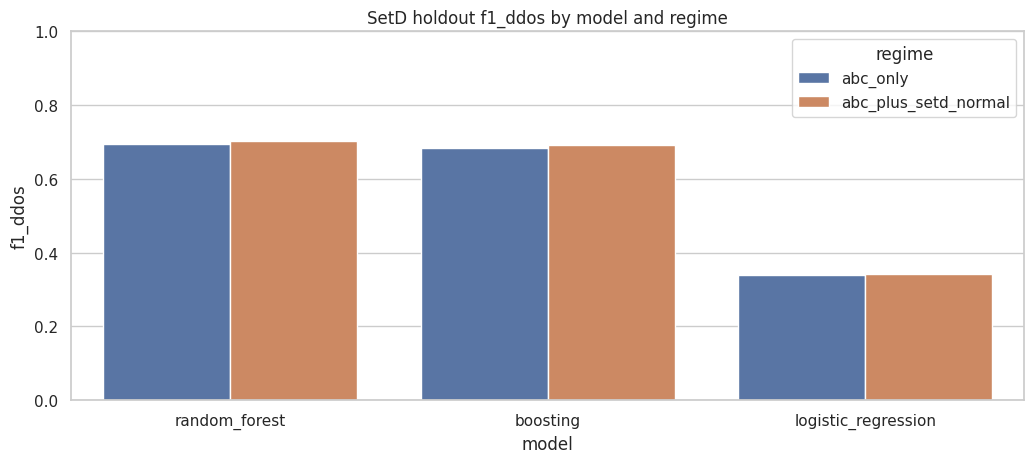

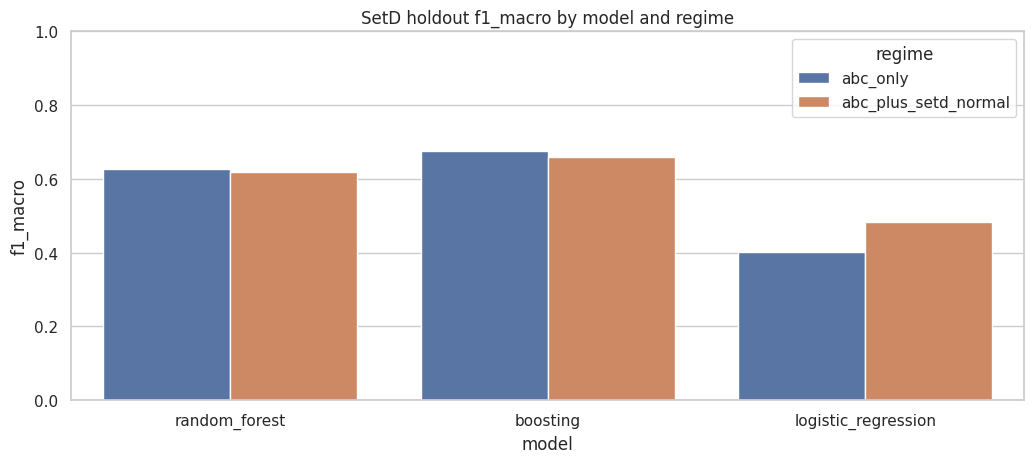

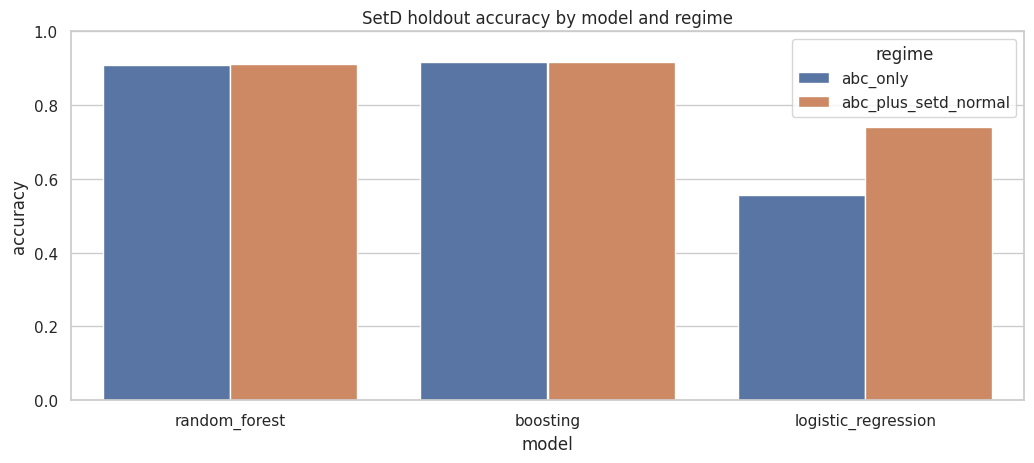

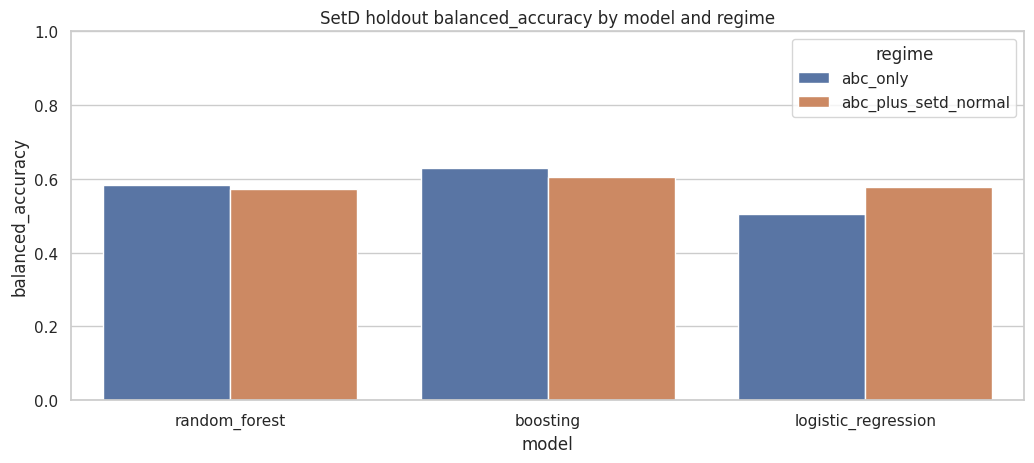

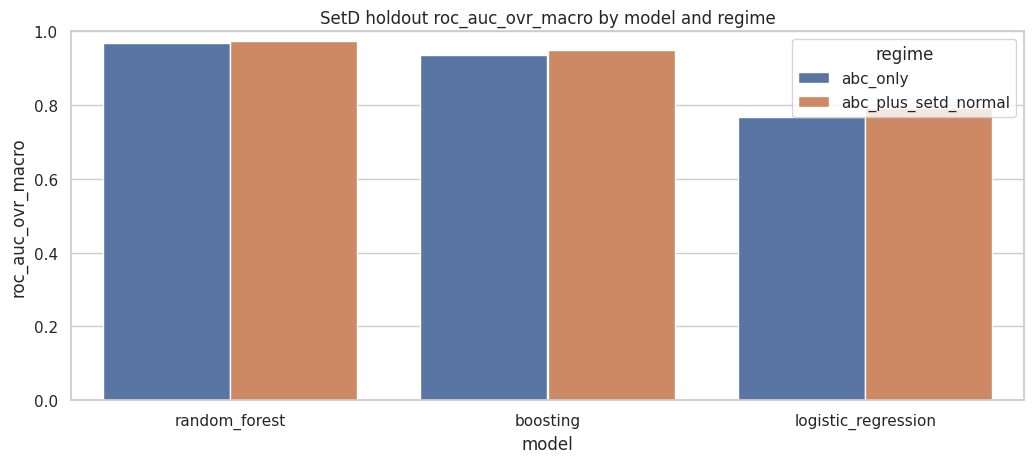

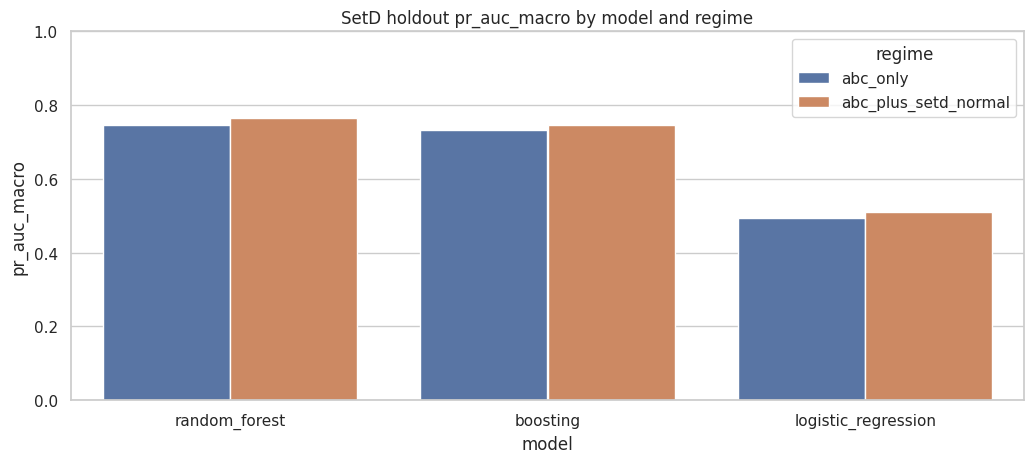

SetD holdout delta (abc_plus_setd_normal - abc_only):


,model,delta_f1_ddos,delta_f1_macro,delta_accuracy,delta_balanced_accuracy,delta_roc_auc_ovr_macro,delta_pr_auc_macro
0,random_forest,0.008575,-0.006117,0.002552,-0.009779,0.005337,0.019485
1,boosting,0.008903,-0.016083,0.000560,-0.023983,0.013223,0.013888
2,logistic_regression,0.003080,0.080240,0.184243,0.071413,0.025302,0.016981


In [12]:
holdout_summary_pivot = final_results_df.pivot_table(
    index=["regime", "model"],
    values=["f1_ddos", "f1_macro", "accuracy", "balanced_accuracy", "roc_auc_ovr_macro", "pr_auc_macro"],
    aggfunc="mean",
)
print("SetD holdout summary:")
display(holdout_summary_pivot)

for metric in ["f1_ddos", "f1_macro", "accuracy", "balanced_accuracy", "roc_auc_ovr_macro", "pr_auc_macro"]:
    plt.figure(figsize=(10.5, 4.8))
    ax = sns.barplot(
        data=final_results_df,
        x="model",
        y=metric,
        hue="regime",
        errorbar=None,
    )
    ax.set_ylim(0, 1)
    ax.set_title(f"SetD holdout {metric} by model and regime")
    plt.tight_layout()
    plt.show()

delta_rows = []
for model_name in MODEL_NAMES:
    base = final_results_df[(final_results_df["model"] == model_name) & (final_results_df["regime"] == "abc_only")]
    mix = final_results_df[(final_results_df["model"] == model_name) & (final_results_df["regime"] == "abc_plus_setd_normal")]
    if len(base) == 1 and len(mix) == 1:
        delta_rows.append({
            "model": model_name,
            "delta_f1_ddos": float(mix.iloc[0]["f1_ddos"] - base.iloc[0]["f1_ddos"]),
            "delta_f1_macro": float(mix.iloc[0]["f1_macro"] - base.iloc[0]["f1_macro"]),
            "delta_accuracy": float(mix.iloc[0]["accuracy"] - base.iloc[0]["accuracy"]),
            "delta_balanced_accuracy": float(mix.iloc[0]["balanced_accuracy"] - base.iloc[0]["balanced_accuracy"]),
            "delta_roc_auc_ovr_macro": float(mix.iloc[0]["roc_auc_ovr_macro"] - base.iloc[0]["roc_auc_ovr_macro"]),
            "delta_pr_auc_macro": float(mix.iloc[0]["pr_auc_macro"] - base.iloc[0]["pr_auc_macro"]),
        })

delta_df = pd.DataFrame(delta_rows)
print("SetD holdout delta (abc_plus_setd_normal - abc_only):")
display(delta_df)

Best run on SetD holdout:


,regime,model,dataset,f1_ddos,accuracy,balanced_accuracy,f1_macro,roc_auc_ovr_macro,pr_auc_macro,fit_time_sec,predict_time_sec,best_params
3,abc_plus_setd_normal,random_forest,setd_holdout,0.702242,0.911455,0.573528,0.619798,0.974419,0.765495,11.415616,0.697177,"{""max_depth"": 30, ""min_samples_leaf"": 4, ""n_es..."


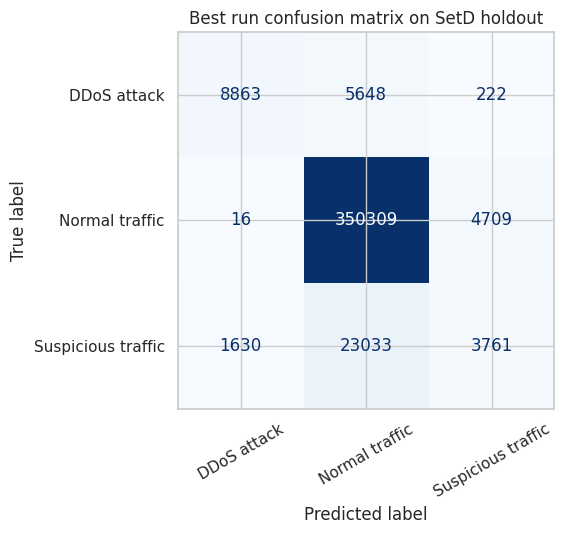

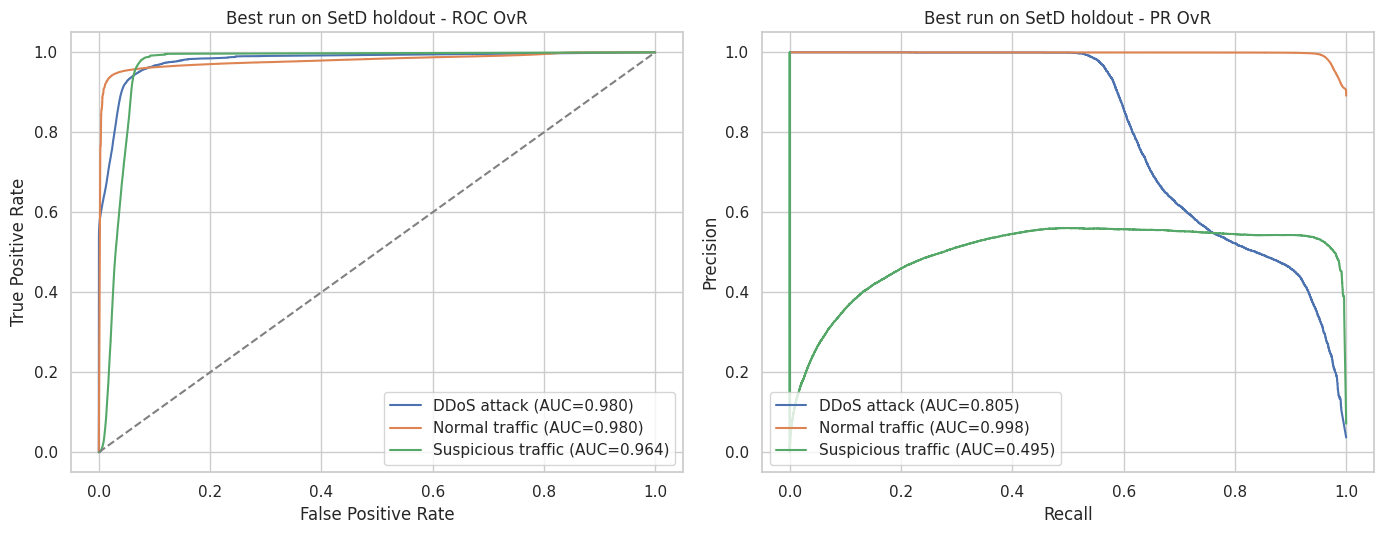

In [13]:
def best_run_on_holdout(results: pd.DataFrame):
    sub = results.copy()
    sub = sub.sort_values(["f1_ddos", "f1_macro", "balanced_accuracy", "accuracy"], ascending=False)
    return sub.iloc[0]

best_holdout = best_run_on_holdout(final_results_df)
print("Best run on SetD holdout:")
display(best_holdout.to_frame().T)

key = (best_holdout["regime"], best_holdout["model"])
payload = final_predictions[key]
y_true = payload["y_true"]
y_pred = payload["y_pred"]
class_labels = payload["class_labels"]

_, ax = plt.subplots(figsize=(6.5, 5.5))
ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    ax=ax,
    cmap="Blues",
    xticks_rotation=30,
    colorbar=False,
    labels=class_labels,
 )
ax.set_title("Best run confusion matrix on SetD holdout")
plt.tight_layout()
plt.show()

def plot_multiclass_roc_pr(y_true, y_proba, class_labels, title_prefix: str):
    y_bin = label_binarize(y_true, classes=class_labels)
    if y_bin.ndim == 1:
        y_bin = y_bin.reshape(-1, 1)

    _, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    roc_any = False
    pr_any = False

    for idx, class_name in enumerate(class_labels):
        if idx >= y_bin.shape[1]:
            continue
        y_class = y_bin[:, idx]
        if y_class.sum() == 0 or y_class.sum() == len(y_class):
            continue

        fpr, tpr, _ = roc_curve(y_class, y_proba[:, idx])
        precision, recall, _ = precision_recall_curve(y_class, y_proba[:, idx])
        roc_auc_val = auc(fpr, tpr)
        pr_auc_val = auc(recall, precision)

        axes[0].plot(fpr, tpr, label=f"{class_name} (AUC={roc_auc_val:.3f})")
        axes[1].plot(recall, precision, label=f"{class_name} (AUC={pr_auc_val:.3f})")
        roc_any = True
        pr_any = True

    axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title(f"{title_prefix} - ROC OvR")
    axes[0].legend(loc="lower right")

    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title(f"{title_prefix} - PR OvR")
    axes[1].legend(loc="lower left")

    plt.tight_layout()
    plt.show()

    if not roc_any or not pr_any:
        print(f"No valid ROC/PR curves could be plotted for {title_prefix}.")

plot_multiclass_roc_pr(
    y_true=payload["y_true"],
    y_proba=payload["y_proba"],
    class_labels=class_labels,
    title_prefix="Best run on SetD holdout",
)

In [14]:
# Persist artifacts
trials_path = OUT_DIR / "optuna_trials_kfold_setd_normal_mix.csv"
fold_metrics_path = OUT_DIR / "optuna_fold_metrics_kfold_setd_normal_mix.csv"
best_fold_metrics_path = OUT_DIR / "optuna_best_trial_fold_metrics_kfold_setd_normal_mix.csv"
best_trials_path = OUT_DIR / "optuna_best_trials_summary_kfold_setd_normal_mix.csv"
best_params_path = OUT_DIR / "best_params_by_regime_model_kfold_setd_normal_mix.json"
final_results_path = OUT_DIR / "final_holdout_comparison_kfold_setd_normal_mix.csv"
delta_path = OUT_DIR / "final_holdout_delta_kfold_setd_normal_mix.csv"
cv_summary_path = OUT_DIR / "final_cv_summary_pivot_kfold_setd_normal_mix.csv"
holdout_summary_path = OUT_DIR / "final_holdout_summary_pivot_kfold_setd_normal_mix.csv"
per_class_path = OUT_DIR / "final_holdout_per_class_metrics_kfold_setd_normal_mix.csv"
roc_pr_path = OUT_DIR / "final_holdout_roc_pr_per_class_kfold_setd_normal_mix.csv"
config_path = OUT_DIR / "kfold_setd_normal_mix_experiment_config.json"

tuning_results_df.to_csv(trials_path, index=False)
fold_metrics_df.to_csv(fold_metrics_path, index=False)
best_fold_metrics_df.to_csv(best_fold_metrics_path, index=False)
best_trials_df.to_csv(best_trials_path, index=False)
final_results_df.to_csv(final_results_path, index=False)
delta_df.to_csv(delta_path, index=False)
cv_summary_pivot.reset_index().to_csv(cv_summary_path, index=False)
holdout_summary_pivot.reset_index().to_csv(holdout_summary_path, index=False)
per_class_metrics_df.to_csv(per_class_path, index=False)
roc_pr_df.to_csv(roc_pr_path, index=False)

best_params_dump = {f"{k[0]}::{k[1]}": v for k, v in best_params_map.items()}
with open(best_params_path, "w", encoding="utf-8") as f:
    json.dump(best_params_dump, f, indent=2)

config_payload = {
    "train_recordings": TRAIN_RECORDINGS,
    "holdout_recording": HOLDOUT_RECORDING,
    "target": TARGET_COL,
    "normal_class": NORMAL_CLASS,
    "normal_sample_frac": NORMAL_SAMPLE_FRAC,
    "random_state": RANDOM_STATE,
    "n_splits": N_SPLITS,
    "models": MODEL_NAMES,
    "regimes": REGIMES,
    "optuna_trials_per_hpo": N_OPTUNA_TRIALS,
    "optuna_target_class": OPTUNA_TARGET_CLASS,
    "best_trial_tie_break": ["mean_f1_ddos", "mean_f1_macro", "mean_balanced_accuracy"],
    "boosting_backend": BOOSTING_BACKEND,
}
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config_payload, f, indent=2)

print("Saved artifacts:")
print(f"- {trials_path}")
print(f"- {fold_metrics_path}")
print(f"- {best_fold_metrics_path}")
print(f"- {best_trials_path}")
print(f"- {best_params_path}")
print(f"- {final_results_path}")
print(f"- {delta_path}")
print(f"- {cv_summary_path}")
print(f"- {holdout_summary_path}")
print(f"- {per_class_path}")
print(f"- {roc_pr_path}")
print(f"- {config_path}")

Saved artifacts:
- ddos-detection/model_comparison_optuna_kfold_setd_normal_mix/optuna_trials_kfold_setd_normal_mix.csv
- ddos-detection/model_comparison_optuna_kfold_setd_normal_mix/optuna_fold_metrics_kfold_setd_normal_mix.csv
- ddos-detection/model_comparison_optuna_kfold_setd_normal_mix/optuna_best_trial_fold_metrics_kfold_setd_normal_mix.csv
- ddos-detection/model_comparison_optuna_kfold_setd_normal_mix/optuna_best_trials_summary_kfold_setd_normal_mix.csv
- ddos-detection/model_comparison_optuna_kfold_setd_normal_mix/best_params_by_regime_model_kfold_setd_normal_mix.json
- ddos-detection/model_comparison_optuna_kfold_setd_normal_mix/final_holdout_comparison_kfold_setd_normal_mix.csv
- ddos-detection/model_comparison_optuna_kfold_setd_normal_mix/final_holdout_delta_kfold_setd_normal_mix.csv
- ddos-detection/model_comparison_optuna_kfold_setd_normal_mix/final_cv_summary_pivot_kfold_setd_normal_mix.csv
- ddos-detection/model_comparison_optuna_kfold_setd_normal_mix/final_holdout_summa

## Notes

- Baseline features only; no PCA and no SMOTE.
- Regime B adds 10% of SetD Normal traffic to the training pool.
- Holdout excludes the sampled normal rows from SetD.
- Objective: mean DDoS F1 across folds (tie-break: mean f1_macro, mean balanced_accuracy).